In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ══════════════════════════════════════════════════════════════════
# numpy for matrix operations
# matplotlib for the scatter plot
# json for loading classification results
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import json
import os

In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — CONFIG AND PATHS
# ══════════════════════════════════════════════════════════════════
# All paths in one place. Uses 4k full hidden states throughout.
# ══════════════════════════════════════════════════════════════════

BASE_PATH  = "/Users/harshaggarwal/Projects_4/hinemo_project/models"
HIDDEN_DIR = f"{BASE_PATH}/hidden_states_full_means_4k_othwerwise_3k"
SAVE_DIR   = f"{BASE_PATH}/figures/phase10a_representational_shift_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

models = [
    "bert-base-multilingual-cased",
    "muril-base-cased",
    "xlm-roberta-base"
]

model_short = {
    "bert-base-multilingual-cased": "mBERT",
    "muril-base-cased"            : "MuRIL",
    "xlm-roberta-base"            : "XLM-R"
}

model_colors = {
    "bert-base-multilingual-cased": "#3498db",
    "muril-base-cased"            : "#2ecc71",
    "xlm-roberta-base"            : "#e74c3c"
}

# Test set macro F1 from original fine-tuning evaluation
test_f1 = {
    "bert-base-multilingual-cased": 0.6810,
    "muril-base-cased"            : 0.7178,
    "xlm-roberta-base"            : 0.7837
}

N_LAYERS = 12
print("Config loaded.")

Config loaded.


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — LINEAR CKA FUNCTION
# ══════════════════════════════════════════════════════════════════
# Same implementation as Phase 9.
# CKA(X, X) = 1.0, CKA of random matrices ≈ 0.
# ══════════════════════════════════════════════════════════════════

def linear_CKA(X, Y):
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)
    XXT = X @ X.T
    YYT = Y @ Y.T
    numerator   = np.sum(XXT * YYT)
    denominator = np.linalg.norm(XXT, "fro") * np.linalg.norm(YYT, "fro")
    return numerator / denominator

print("CKA function defined.")

CKA function defined.


In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — COMPUTE REPRESENTATIONAL SHIFT SCORE PER MODEL
# ══════════════════════════════════════════════════════════════════
# For each layer, compute CKA(pretrained_layer, finetuned_layer).
# High CKA = fine-tuning barely changed that layer's geometry.
# Low CKA  = fine-tuning dramatically reorganized that layer.
#
# Representational Stability Score = mean CKA across all 12 layers
# Representational Shift Score     = 1 - Stability Score
#
# High shift = large reorganization during fine-tuning.
# ══════════════════════════════════════════════════════════════════

shift_results = {}

for model in models:
    print(f"\n── {model_short[model]} ──")

    # Load pretrained and finetuned hidden states
    h_pre  = np.load(f"{HIDDEN_DIR}/{model}/hidden_pretrained_full.npy")
    h_fine = np.load(f"{HIDDEN_DIR}/{model}/hidden_finetuned_full.npy")

    print(f"  Pretrained shape:  {h_pre.shape}")
    print(f"  Finetuned shape:   {h_fine.shape}")

    # Compute CKA between pretrained and finetuned at each layer
    cka_per_layer = []
    for layer in range(N_LAYERS):
        cka_val = linear_CKA(h_pre[:, layer, :], h_fine[:, layer, :])
        cka_per_layer.append(cka_val)
        print(f"  Layer {layer+1:2d}: CKA(pretrained, finetuned) = {cka_val:.4f}")

    # Stability = mean CKA (how similar pretrained and finetuned are)
    stability_score = np.mean(cka_per_layer)

    # Shift = how much changed (1 - stability)
    shift_score = 1 - stability_score

    shift_results[model] = {
        "cka_per_layer"   : cka_per_layer,
        "stability_score" : stability_score,
        "shift_score"     : shift_score,
        "test_f1"         : test_f1[model]
    }

    print(f"\n  Stability Score: {stability_score:.4f}")
    print(f"  Shift Score:     {shift_score:.4f}")
    print(f"  Test Macro F1:   {test_f1[model]:.4f}")


── mBERT ──
  Pretrained shape:  (4000, 12, 768)
  Finetuned shape:   (4000, 12, 768)
  Layer  1: CKA(pretrained, finetuned) = 0.9308
  Layer  2: CKA(pretrained, finetuned) = 0.9082
  Layer  3: CKA(pretrained, finetuned) = 0.9216
  Layer  4: CKA(pretrained, finetuned) = 0.9339
  Layer  5: CKA(pretrained, finetuned) = 0.3122
  Layer  6: CKA(pretrained, finetuned) = 0.2444
  Layer  7: CKA(pretrained, finetuned) = 0.1877
  Layer  8: CKA(pretrained, finetuned) = 0.1530
  Layer  9: CKA(pretrained, finetuned) = 0.1355
  Layer 10: CKA(pretrained, finetuned) = 0.1214
  Layer 11: CKA(pretrained, finetuned) = 0.1204
  Layer 12: CKA(pretrained, finetuned) = 0.0997

  Stability Score: 0.4224
  Shift Score:     0.5776
  Test Macro F1:   0.6810

── MuRIL ──
  Pretrained shape:  (4000, 12, 768)
  Finetuned shape:   (4000, 12, 768)
  Layer  1: CKA(pretrained, finetuned) = 0.9567
  Layer  2: CKA(pretrained, finetuned) = 0.9426
  Layer  3: CKA(pretrained, finetuned) = 0.4063
  Layer  4: CKA(pretrained,

In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════
# Print shift scores and F1 side by side to see the relationship.
# ══════════════════════════════════════════════════════════════════

print(f"\n{'Model':<10} {'Stability':<12} {'Shift Score':<14} {'Test F1'}")
print("-" * 50)

for model in models:
    r = shift_results[model]
    print(f"{model_short[model]:<10} {r['stability_score']:<12.4f} "
          f"{r['shift_score']:<14.4f} {r['test_f1']:.4f}")

print("\nIf shift score increases monotonically with F1,")
print("representational reorganization predicts task performance.")


Model      Stability    Shift Score    Test F1
--------------------------------------------------
mBERT      0.4224       0.5776         0.6810
MuRIL      0.3919       0.6081         0.7178
XLM-R      0.3966       0.6034         0.7837

If shift score increases monotonically with F1,
representational reorganization predicts task performance.


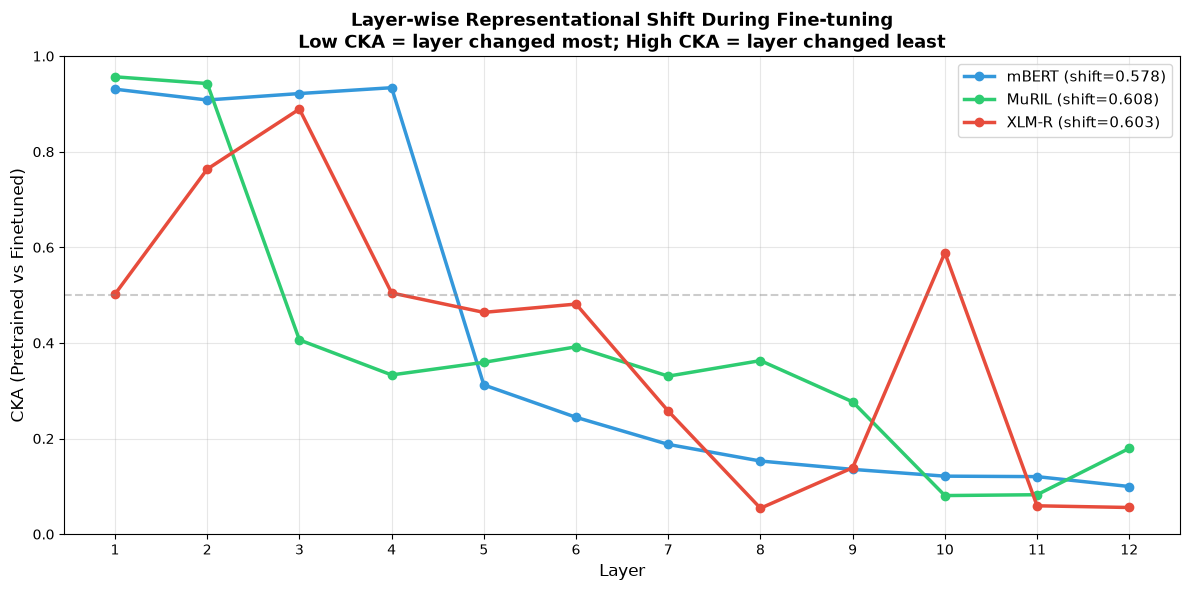

Saved.


In [6]:
# ══════════════════════════════════════════════════════════════════
# CELL 6 — LAYER-WISE CROSS-STATE CKA CURVES
# ══════════════════════════════════════════════════════════════════
# X-axis = layer (1-12)
# Y-axis = CKA between pretrained and finetuned at that layer
# Low values = layers that changed most during fine-tuning
# High values = layers that changed least (most stable)
# ══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

for model in models:
    r = shift_results[model]
    ax.plot(range(1, 13), r["cka_per_layer"],
            label=f"{model_short[model]} (shift={r['shift_score']:.3f})",
            color=model_colors[model],
            linewidth=2.5,
            marker="o",
            markersize=6)

ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("CKA (Pretrained vs Finetuned)", fontsize=12)
ax.set_title("Layer-wise Representational Shift During Fine-tuning\n"
             "Low CKA = layer changed most; High CKA = layer changed least",
             fontsize=13, fontweight="bold")
ax.set_xticks(range(1, 13))
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="midpoint")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/layerwise_shift_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

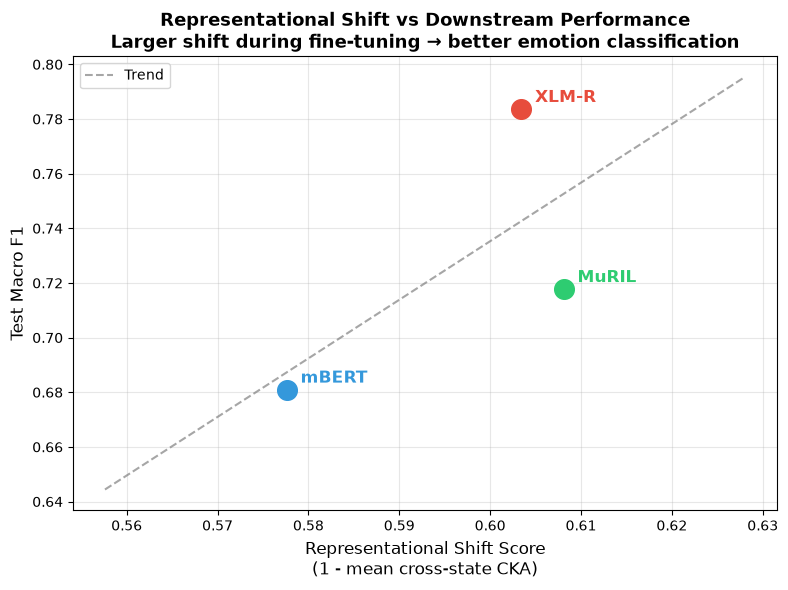

Saved.


In [7]:
# ══════════════════════════════════════════════════════════════════
# CELL 7 — SCATTER PLOT: SHIFT SCORE VS TEST F1
# ══════════════════════════════════════════════════════════════════
# Three points, one per model.
# X-axis = Representational Shift Score (how much changed)
# Y-axis = Test Macro F1 (how well it performs)
# If the points form a line from bottom-left to top-right,
# reorganization magnitude predicts downstream performance.
# ══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 6))

shift_scores = [shift_results[m]["shift_score"] for m in models]
f1_scores    = [shift_results[m]["test_f1"] for m in models]
labels       = [model_short[m] for m in models]
colors       = [model_colors[m] for m in models]

for i, model in enumerate(models):
    ax.scatter(shift_scores[i], f1_scores[i],
               color=colors[i],
               s=200,
               zorder=5)
    ax.annotate(labels[i],
                (shift_scores[i], f1_scores[i]),
                textcoords="offset points",
                xytext=(10, 5),
                fontsize=12,
                fontweight="bold",
                color=colors[i])

# Add a trend line
z    = np.polyfit(shift_scores, f1_scores, 1)
p    = np.poly1d(z)
x_line = np.linspace(min(shift_scores)-0.02, max(shift_scores)+0.02, 100)
ax.plot(x_line, p(x_line),
        color="gray",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        label="Trend")

ax.set_xlabel("Representational Shift Score\n(1 - mean cross-state CKA)",
              fontsize=12)
ax.set_ylabel("Test Macro F1", fontsize=12)
ax.set_title("Representational Shift vs Downstream Performance\n"
             "Larger shift during fine-tuning → better emotion classification",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/shift_vs_f1_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [11]:
# ══════════════════════════════════════════════════════════════════
# CELL 8 — SAVE RESULTS
# ══════════════════════════════════════════════════════════════════
# Saves shift scores and per-layer CKA values.
# Note: global and early-layer shift scores did not cleanly predict
# downstream F1 across models. The meaningful finding is the
# LOCATION of the CKA drop per model, which matches the LSL from
# Phase 7a exactly. The layer-wise curve figure captures this.
# The scatter plot (shift score vs F1) was dropped.
# ══════════════════════════════════════════════════════════════════

save_path = f"{BASE_PATH}/phase10a_representational_shift_results.json"

early_layers = [0, 1, 2, 3]

with open(save_path, "w") as f:
    json.dump({
        model_short[m]: {
            "stability_score"  : float(shift_results[m]["stability_score"]),
            "shift_score_global": float(shift_results[m]["shift_score"]),
            "shift_score_early" : float(1 - np.mean([shift_results[m]["cka_per_layer"][i] 
                                                      for i in early_layers])),
            "test_f1"          : float(shift_results[m]["test_f1"]),
            "cka_per_layer"    : [float(v) for v in shift_results[m]["cka_per_layer"]],
            "finding"          : "CKA drop location matches Phase 7a LSL — not magnitude"
        }
        for m in models
    }, f, indent=2)

print(f"Saved to {save_path}")
print("\nKey finding from Phase 10a:")
print("  mBERT  — CKA drops at layer 5  → LSL=4  ✓")
print("  MuRIL  — CKA drops at layer 3  → LSL=3  ✓")
print("  XLM-R  — CKA low from layer 1  → LSL=1  ✓")
print("\nScatter plot dropped — global/early shift scores")
print("do not cleanly distinguish MuRIL from XLM-R.")

Saved to /Users/harshaggarwal/Projects_4/hinemo_project/models/phase10a_representational_shift_results.json

Key finding from Phase 10a:
  mBERT  — CKA drops at layer 5  → LSL=4  ✓
  MuRIL  — CKA drops at layer 3  → LSL=3  ✓
  XLM-R  — CKA low from layer 1  → LSL=1  ✓

Scatter plot dropped — global/early shift scores
do not cleanly distinguish MuRIL from XLM-R.


In [10]:
# ══════════════════════════════════════════════════════════════════
# CELL 9 — EARLY-LAYER SHIFT SCORE (LAYERS 1-4 ONLY)
# ══════════════════════════════════════════════════════════════════
# The global shift score averaged across all 12 layers didn't
# cleanly predict F1 because MuRIL and XLM-R had similar averages.
# The language encoding shift happens specifically in early layers
# (per Phase 7a LSLs: mBERT=4, MuRIL=3, XLM-R=1).
# This cell computes shift score using only layers 1-4 to see
# if early-layer reorganization is the better predictor.
# ══════════════════════════════════════════════════════════════════

early_layers = [0, 1, 2, 3]  # indices 0-3 = layers 1-4

print(f"{'Model':<10} {'Early Shift (L1-4)':<22} {'Global Shift':<16} {'Test F1'}")
print("-" * 60)

for model in models:
    r         = shift_results[model]
    early_cka = np.mean([r["cka_per_layer"][i] for i in early_layers])
    early_shift = 1 - early_cka

    print(f"{model_short[model]:<10} {early_shift:<22.4f} "
          f"{r['shift_score']:<16.4f} {r['test_f1']:.4f}")

Model      Early Shift (L1-4)     Global Shift     Test F1
------------------------------------------------------------
mBERT      0.0764                 0.5776           0.6810
MuRIL      0.3403                 0.6081           0.7178
XLM-R      0.3352                 0.6034           0.7837
